In [1]:
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# seed = 62786278

# np.random.seed(seed)
# np.random.seed(seed)
# torch.manual_seed(seed)

## DATA PREP

In [2]:
df = pd.read_csv("../data/newport_raw.csv", dtype=str)

In [3]:
df.columns = df.columns.str.lower()
visits_cols = [f"visits_h{x}" for x in range(168)]

df[visits_cols] = df[visits_cols].apply(pd.to_numeric, errors="coerce")

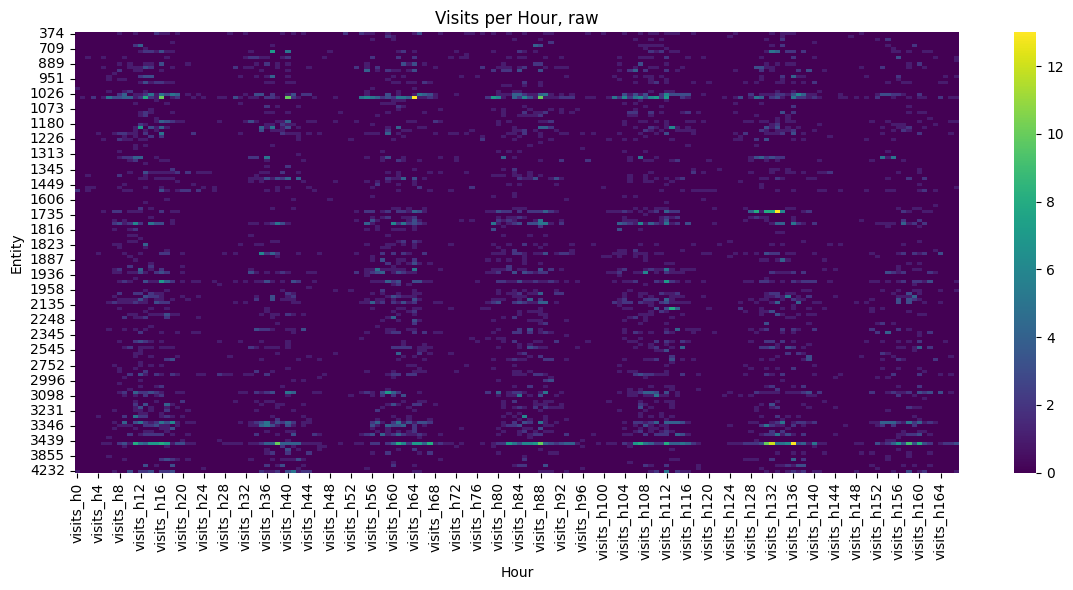

In [4]:
# Extract just the nonmissing visits data
visits_data = df[visits_cols].astype(float).dropna()

# Heatmap of raw data
plt.figure(figsize=(12, 6))
sns.heatmap(visits_data, cmap="viridis", cbar=True)

plt.xlabel("Hour")
plt.ylabel("Entity")
plt.title("Visits per Hour, raw")
plt.tight_layout()
plt.show()

In [5]:
dat = df.dropna(subset=visits_cols)  # training set

dat = dat.melt(
    id_vars=["prim_occ", "sqmeters", "build_id"],
    value_vars=visits_cols,
    var_name="hour_of_week",
    value_name="visits",
)
dat["hour_of_week"] = dat["hour_of_week"].str.extract(r"(\d+)").astype(int)
dat["sqmeters"] = pd.to_numeric(dat["sqmeters"], errors="coerce")
dat["hour_d"] = dat["hour_of_week"] % 24  # 0-23
dat["sin_hod"] = np.sin(2 * np.pi * dat["hour_d"] / 24)
dat["cos_hod"] = np.cos(2 * np.pi * dat["hour_d"] / 24)


dat["day_w"] = dat["hour_of_week"] // 24  # 0-6
dat["sin_dow"] = np.sin(2 * np.pi * dat["day_w"] / 7)
dat["cos_dow"] = np.cos(2 * np.pi * dat["day_w"] / 7)


dat["sqmeters_scaled"] = dat["sqmeters"] / dat["sqmeters"].max()
dat["log_sqmeters"] = np.log(dat["sqmeters"])

dat["sq_q"] = pd.qcut(dat["sqmeters_scaled"], 4, labels=False)

dat["x_prim_occ"] = dat["prim_occ"].astype("category").cat.codes

In [6]:
# split into train and test set, random building x time points

# from sklearn.model_selection import train_test_split
# tr, test, y_tr, y_test = train_test_split(
#     dat.drop('visits', axis = 1), dat['visits'], test_size=0.2, random_state=42)

# Hold out 10% of buildings
builds = dat["build_id"].unique()
rng = np.random.default_rng()
builds = rng.choice(builds, len(builds) // 10)

mask = dat["build_id"].isin(builds)
tr = dat[~mask].drop("visits", axis=1)
test = dat[mask].drop("visits", axis=1)

y_tr = dat[~mask]["visits"]
y_test = dat[mask]["visits"]

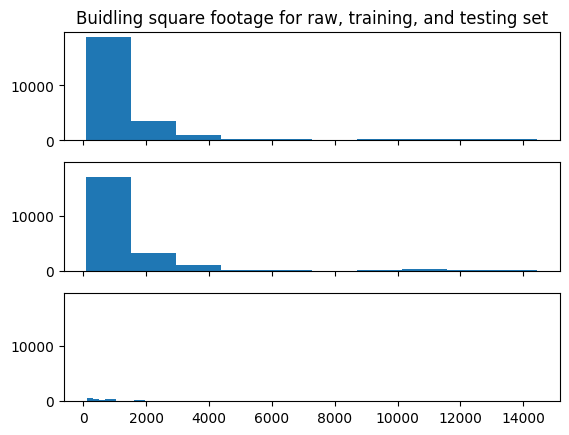

In [7]:
fig, axes = plt.subplots(3, sharex=True, sharey=True)
axes.flatten()[0].hist(dat["sqmeters"])
axes.flatten()[1].hist(tr["sqmeters"])
axes.flatten()[2].hist(test["sqmeters"])
axes.flatten()[0].set_title(
    "Buidling square footage for raw, training, and testing set"
)
fig.show()

In [12]:
x_sin_hod = torch.tensor(tr["sin_hod"].values, dtype=torch.float32).unsqueeze(1)
x_cos_hod = torch.tensor(tr["cos_hod"].values, dtype=torch.float32).unsqueeze(1)
x_area = torch.tensor(tr["sqmeters_scaled"].values, dtype=torch.float32).unsqueeze(1)
x_sin_dow = torch.tensor(tr["sin_dow"].values, dtype=torch.float32).unsqueeze(1)
x_cos_dow = torch.tensor(tr["cos_dow"].values, dtype=torch.float32).unsqueeze(1)
x_type = torch.tensor(tr["x_prim_occ"].values, dtype=torch.long)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cpu')

y = torch.tensor(y_tr.values, dtype=torch.float32).unsqueeze(1)

x_sin_hod = x_sin_hod.to(device)
x_cos_hod = x_cos_hod.to(device)
x_area = x_area.to(device)
x_sin_dow = x_sin_dow.to(device)
x_cos_dow = x_cos_dow.to(device)
y = y.to(device)

# Training


In [13]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        input_size = 5 + 5
        hidden_size = 32
        output_size = 1

        self.type_emb = nn.Embedding(13, 5)

        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size),
        )

    def forward(self, x_sin_hod, x_cos_hod, x_area, x_sin_dow, x_cos_dow, x_type):
        x_type_emb = self.type_emb(x_type)
        x = torch.cat(
            [x_sin_hod, x_cos_hod, x_area, x_sin_dow, x_cos_dow, x_type_emb], dim=1
        )
        return self.net(x)

In [10]:
loss_fn = nn.PoissonNLLLoss(log_input=True)

In [23]:
n_learners = 1
num_epochs = 1000
boost_lr = 0.1

learners = []

for m in range(n_learners):

    print(f"\nTraining learner {m+1}/{n_learners}")

    model = Net().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # Freeze previous learners
    for mdl in learners:
        mdl.eval()
        for p in mdl.parameters():
            p.requires_grad_(False)

    # Compute previous ensemble log-rate
    with torch.no_grad():
        if learners:
            prev_log_rate = learners[0](
                x_sin_hod, x_cos_hod, x_area, x_sin_dow, x_cos_dow, x_type
            ) + sum(boost_lr * mdl(x_sin_hod, x_cos_hod, x_area, x_sin_dow, x_cos_dow, x_type)
                for mdl in learners[1:])
        else:
            prev_log_rate = torch.zeros_like(y)

    for epoch in range(num_epochs):

        model.train()
        optimizer.zero_grad()

        current_log_rate = model(x_sin_hod, x_cos_hod, x_area, x_sin_dow, x_cos_dow, x_type)

        if not learners:
            ensemble_log_rate = current_log_rate
        else:
            ensemble_log_rate = prev_log_rate + boost_lr * current_log_rate

        loss = loss_fn(ensemble_log_rate, y)

        loss.backward()
        optimizer.step()

        if epoch % 50 == 0:
            print(f"Epoch {epoch:4d} | Loss = {loss.item():.6f}")

    model.eval()
    learners.append(model)


Training learner 1/1
Epoch    0 | Loss = 1.184652
Epoch   50 | Loss = 0.542084
Epoch  100 | Loss = 0.456626
Epoch  150 | Loss = 0.391080
Epoch  200 | Loss = 0.370056
Epoch  250 | Loss = 0.362272
Epoch  300 | Loss = 0.354405
Epoch  350 | Loss = 0.347479
Epoch  400 | Loss = 0.340630
Epoch  450 | Loss = 0.333358
Epoch  500 | Loss = 0.324449
Epoch  550 | Loss = 0.315786
Epoch  600 | Loss = 0.308702
Epoch  650 | Loss = 0.303399
Epoch  700 | Loss = 0.298796
Epoch  750 | Loss = 0.295137
Epoch  800 | Loss = 0.291543
Epoch  850 | Loss = 0.288242
Epoch  900 | Loss = 0.284971
Epoch  950 | Loss = 0.282262


In [24]:
import torch
import torch.nn as nn

loss_fn = nn.PoissonNLLLoss(log_input=True)

for run in range(10):

    model = Net().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(2000):

        optimizer.zero_grad()

        log_rate = model(
            x_sin_hod,
            x_cos_hod,
            x_area,
            x_sin_dow,
            x_cos_dow,
            x_type,
        )

        loss = loss_fn(log_rate, y)

        loss.backward()
        optimizer.step()

    print(f"Run {run + 1}: {loss.item():.6f}")

Run 1: 0.220634
Run 2: 0.204058
Run 3: 0.219744
Run 4: 0.219733
Run 5: 0.236662
Run 6: 0.252402
Run 7: 0.199016
Run 8: 0.227825
Run 9: 0.232243
Run 10: 0.219413


# Validation

In [25]:
for mdl in learners:
    mdl.eval()
    
x_sin_hod = (
    torch.tensor(test["sin_hod"].values, dtype=torch.float32).unsqueeze(1).to(device)
)
x_cos_hod = (
    torch.tensor(test["cos_hod"].values, dtype=torch.float32).unsqueeze(1).to(device)
)
x_area = (
    torch.tensor(test["log_sqmeters"].values, dtype=torch.float32)
    .unsqueeze(1)
    .to(device)
)
x_sin_dow = (
    torch.tensor(test["sin_dow"].values, dtype=torch.float32).unsqueeze(1).to(device)
)
x_cos_dow = (
    torch.tensor(test["cos_dow"].values, dtype=torch.float32).unsqueeze(1).to(device)
)
x_type = torch.tensor(test["x_prim_occ"].values, dtype=torch.long).to(device)

y = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)


with torch.no_grad():

    ensemble_log_rate = learners[0](
        x_sin_hod, x_cos_hod, x_area, x_sin_dow, x_cos_dow, x_type
    ) + sum(
        boost_lr
        * mdl(x_sin_hod, x_cos_hod,
            x_area,
            x_sin_dow,
            x_cos_dow,
            x_type,
        )
        for mdl in learners[1:]
    )

    pred = torch.exp(ensemble_log_rate).cpu().squeeze()
    obs = y.detach().cpu().squeeze().numpy()

df_pred = pd.DataFrame(
    {
        "build_id": test["build_id"],
        "type": test["prim_occ"],
        "day_w": test["day_w"],
        "hour_d": test["hour_d"],
        "sq_q": test["sq_q"],
        "pred": pred,
        "obs": obs,
    }
)

df_grp = (
    df_pred.groupby(["type", "day_w", "hour_d"], observed=True)[["pred", "obs"]]
    .mean()
    .reset_index()
)


known_categories = set(tr["prim_occ"].unique())

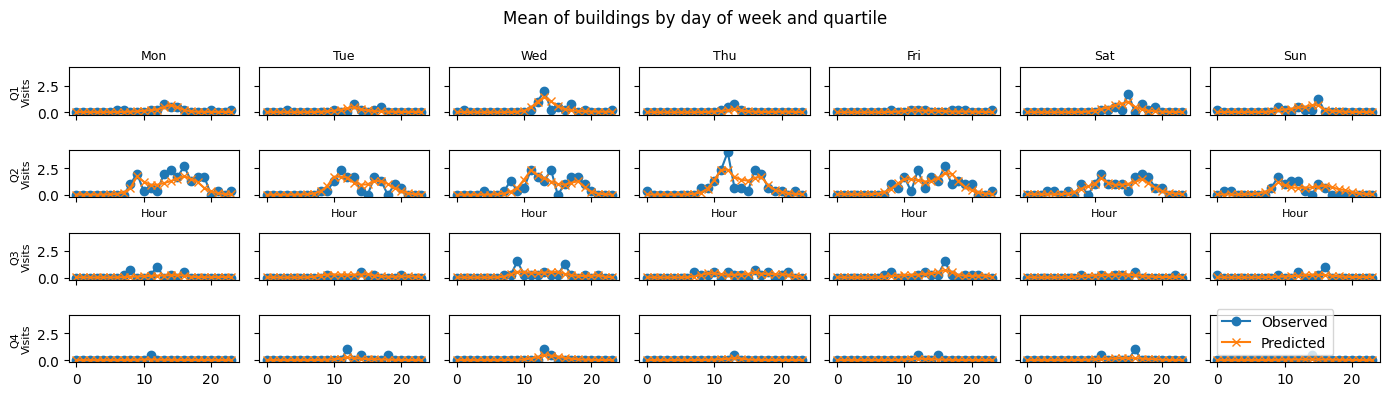

In [29]:
# Parameters
quartiles = [0, 1, 2, 3]  # Q1 and Q4
dow = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
days = [0, 1, 2, 3, 4, 5, 6]

# Set up plot grid: 2 rows (Q1 and Q4), 7 columns (days)
fig, axes = plt.subplots(4, 7, figsize=(14, 4), sharex=True, sharey=True)
axes = np.atleast_2d(axes)

for row, q in enumerate(quartiles):
    for col, day in enumerate(days):
        ax = axes[row, col]
        mask = (df_pred["day_w"] == day) & (df_pred["sq_q"] == q)
        sub = df_pred[mask]

        if not sub.empty:
            grp = sub.groupby("hour_d", observed=True)[["obs", "pred"]].mean()
            ax.plot(grp.index, grp["obs"], marker="o", label="Observed")
            ax.plot(grp.index, grp["pred"], marker="x", label="Predicted")

        if col == 0:
            ax.set_ylabel(f"Q{q+1}\nVisits", fontsize=8)
        if row == 1:
            ax.set_xlabel("Hour", fontsize=8)
        if row == 0:
            ax.set_title(dow[day], fontsize=9)

fig.suptitle("Mean of buildings by day of week and quartile")
plt.tight_layout()
plt.legend()
plt.show()

/tmp/ipykernel_2166615/682447136.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  build_preds["hour_w"] = build_preds["day_w"] * 24 + build_preds["hour_d"]


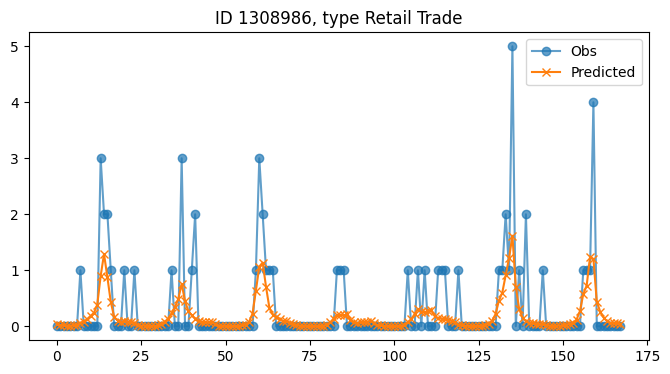

In [26]:
test_builds = df_pred["build_id"].unique()
rand = np.random.default_rng()

build = rand.choice(test_builds)
build_preds = df_pred[df_pred["build_id"] == build]
build_preds["hour_w"] = build_preds["day_w"] * 24 + build_preds["hour_d"]

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(build_preds["hour_w"], build_preds["obs"], marker="o", alpha=0.7, label="Obs")
ax.plot(build_preds["hour_w"], build_preds["pred"], marker="x", label="Predicted")

plt.title(f"ID {build_preds['build_id'].iloc[0]}, type {build_preds['type'].iloc[0]}")
plt.legend()

In [27]:
# confirm no leakage of test data into train
print(tr[tr["build_id"] == 1308986])
print(tr[tr["build_id"] == '1308986'])

Empty DataFrame
Columns: [prim_occ, sqmeters, build_id, hour_of_week, hour_d, sin_hod, cos_hod, day_w, sin_dow, cos_dow, sqmeters_scaled, log_sqmeters, sq_q, x_prim_occ]
Index: []
Empty DataFrame
Columns: [prim_occ, sqmeters, build_id, hour_of_week, hour_d, sin_hod, cos_hod, day_w, sin_dow, cos_dow, sqmeters_scaled, log_sqmeters, sq_q, x_prim_occ]
Index: []


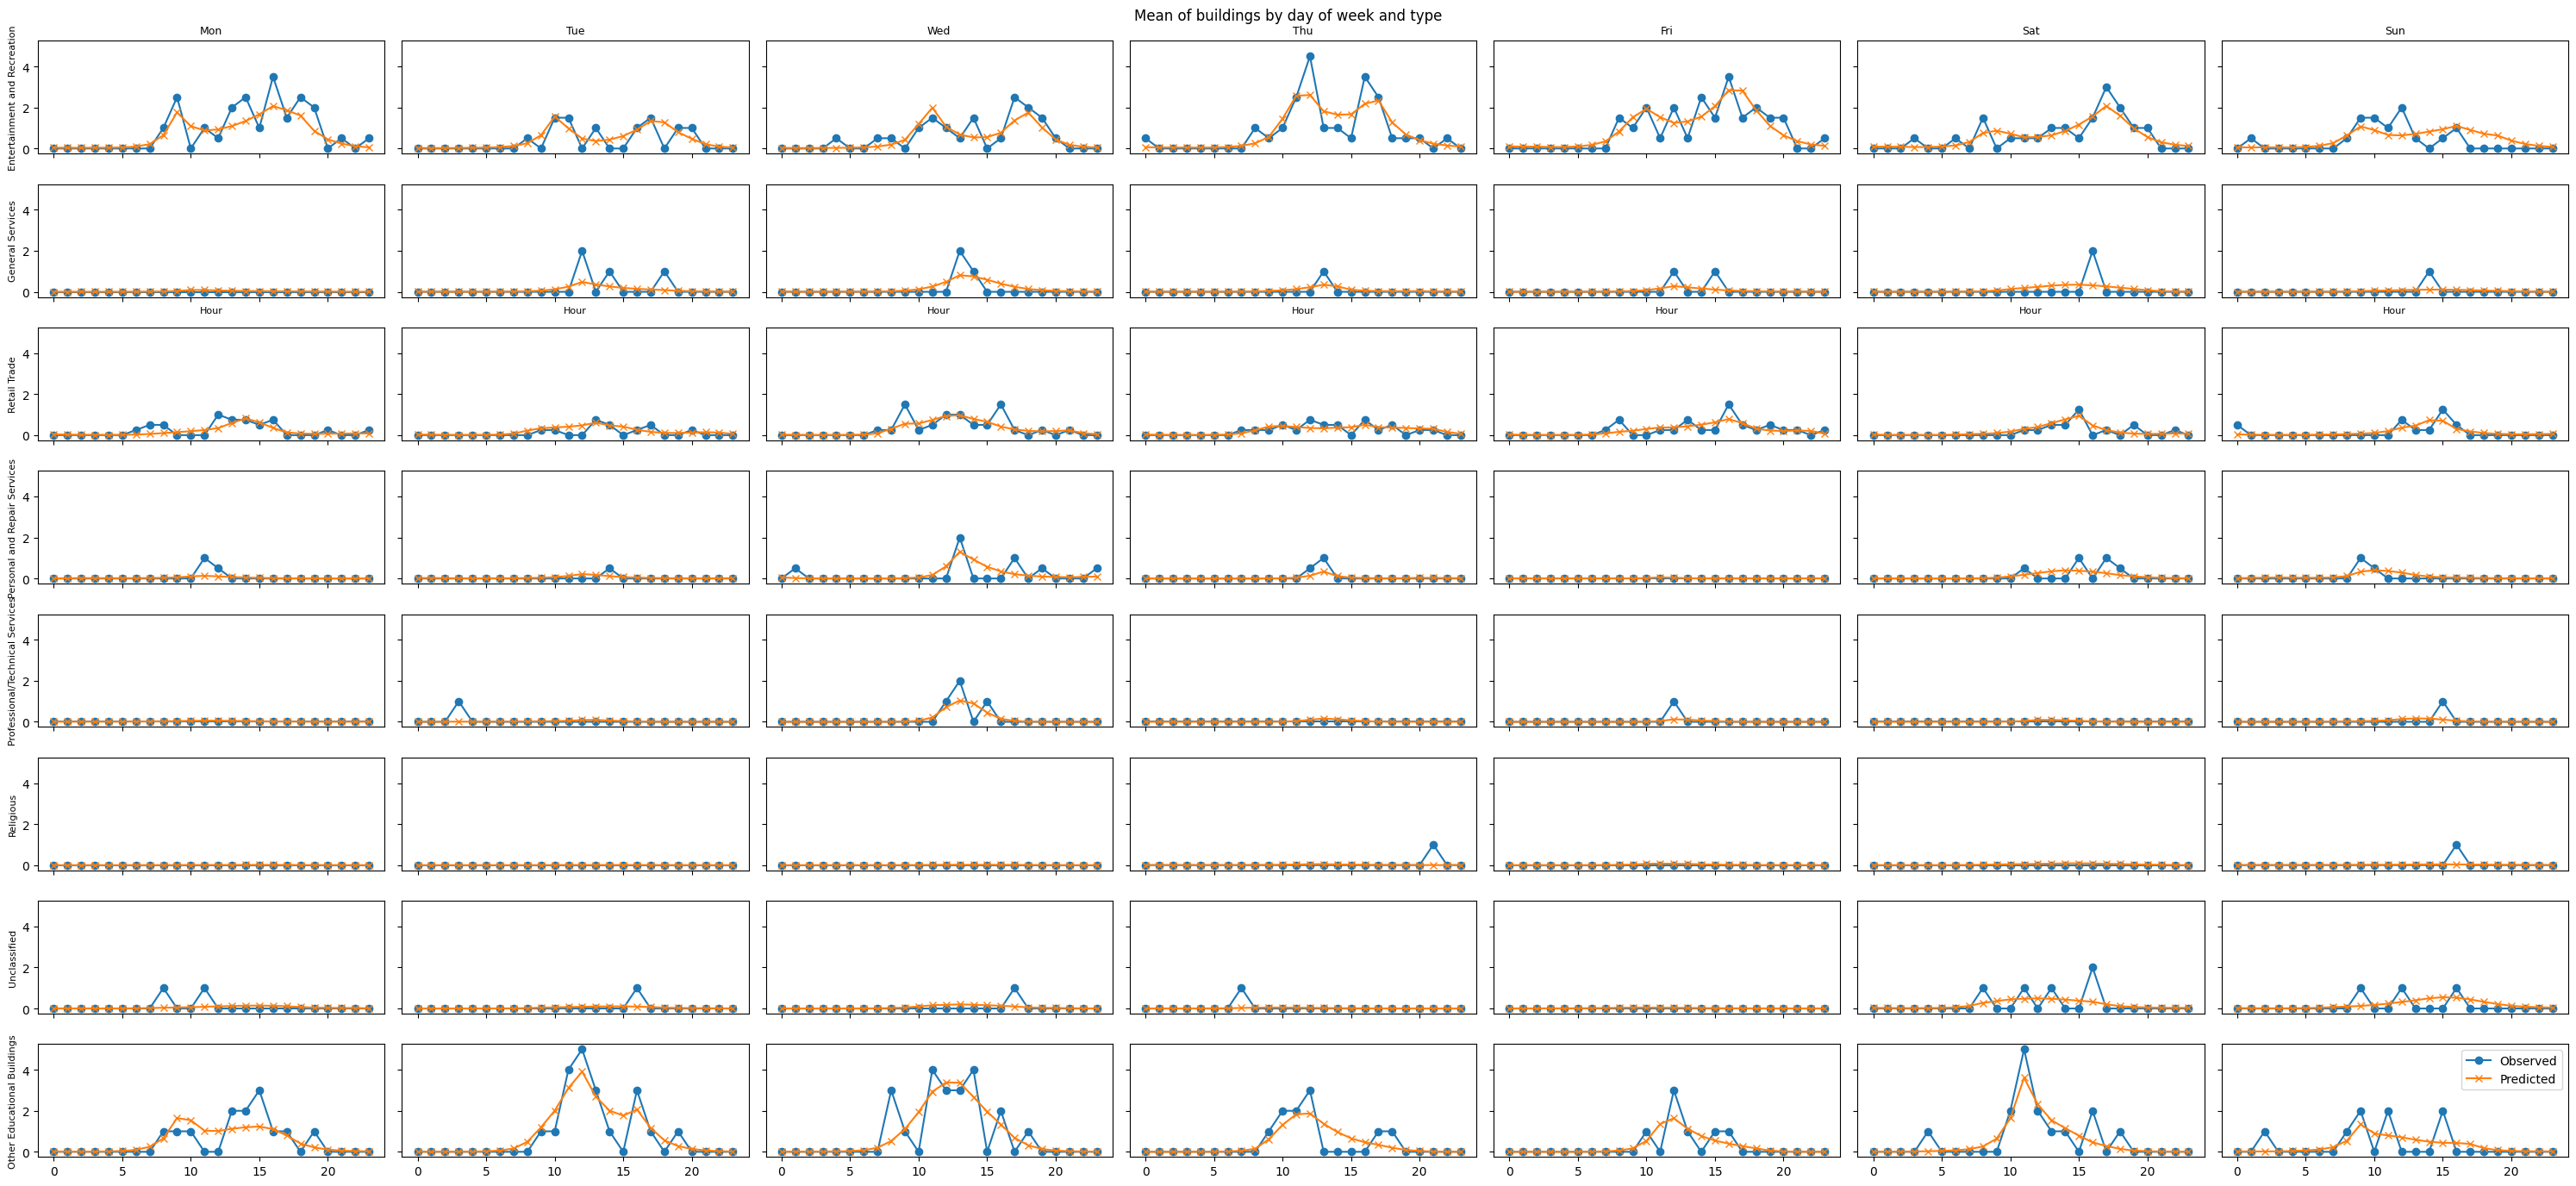

In [28]:
# Parameters
categories = df_pred["type"].unique()
n_cats = len(categories)
dow = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
days = [0, 1, 2, 3, 4, 5, 6]

# Set up plot grid: 2 rows (Q1 and Q4), 7 columns (days)
fig, axes = plt.subplots(n_cats, 7, figsize=(30, 14), sharex=True, sharey=True)
axes = np.atleast_2d(axes)

for row, q in enumerate(categories):
    for col, day in enumerate(days):
        ax = axes[row, col]
        mask = (df_pred["day_w"] == day) & (df_pred["type"] == q)
        sub = df_pred[mask]

        if not sub.empty:
            grp = sub.groupby("hour_d", observed=True)[["obs", "pred"]].mean()
            ax.plot(grp.index, grp["obs"], marker="o", label="Observed")
            ax.plot(grp.index, grp["pred"], marker="x", label="Predicted")

        if col == 0:
            ax.set_ylabel(f"{q}", fontsize=8)
        if row == 1:
            ax.set_xlabel("Hour", fontsize=8)
        if row == 0:
            ax.set_title(dow[day], fontsize=9)

fig.suptitle("Mean of buildings by day of week and type")
plt.tight_layout()
plt.legend()
plt.show()

In [30]:
df_pred = pd.DataFrame(
    {
        "build_id": test["build_id"],
        "type": test["prim_occ"],
        "day_w": test["day_w"],
        "hour_d": test["hour_d"],
        "sq_q": test["sq_q"],
        "pred": pred,
        "obs": obs,
    }
)

df_grp = (
    df_pred.groupby(["type", "day_w", "hour_d"], observed=True)[["pred", "obs"]]
    .mean()
    .reset_index()
)


known_categories = set(tr["prim_occ"].unique())

Text(0.5, 1.0, 'pred vs obs')

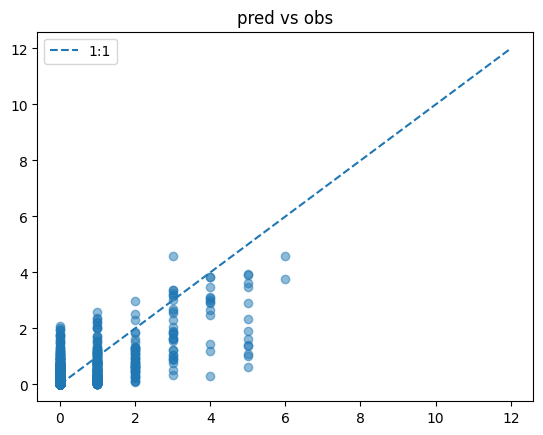

In [31]:
plt.scatter(df_pred["obs"], df_pred["pred"], alpha=0.5)
plt.plot([0, 12], [0, 12], linestyle="--", label="1:1")
plt.legend()
plt.title("pred vs obs")

In [39]:
torch.save(model.state_dict(), 'model_weights.pth')

# Adding noise (may not need due to variability in neural network)

In [38]:
cpu_rng_state = torch.get_rng_state()
print(*cpu_rng_state.cpu().squeeze().numpy())

163 223 174 130 131 168 82 66 223 1 0 0 1 0 0 0 146 0 0 0 0 0 0 0 28 69 159 125 0 0 0 0 214 84 197 136 0 0 0 0 93 147 117 107 0 0 0 0 37 123 9 217 0 0 0 0 75 231 176 54 0 0 0 0 3 112 3 157 0 0 0 0 207 63 31 241 0 0 0 0 141 48 214 248 0 0 0 0 53 206 105 109 0 0 0 0 189 76 171 23 0 0 0 0 58 64 98 31 0 0 0 0 118 163 198 36 0 0 0 0 134 129 206 99 0 0 0 0 130 71 253 128 0 0 0 0 106 137 129 173 0 0 0 0 112 63 73 114 0 0 0 0 202 75 201 56 0 0 0 0 126 114 77 93 0 0 0 0 55 228 154 17 0 0 0 0 242 225 29 211 0 0 0 0 253 16 61 113 0 0 0 0 30 12 63 1 0 0 0 0 30 53 105 49 0 0 0 0 52 232 142 93 0 0 0 0 136 66 231 214 0 0 0 0 0 217 68 151 0 0 0 0 132 73 62 251 0 0 0 0 160 10 89 5 0 0 0 0 51 41 236 53 0 0 0 0 98 223 83 96 0 0 0 0 214 168 110 3 0 0 0 0 145 38 179 228 0 0 0 0 185 73 28 154 0 0 0 0 171 240 43 118 0 0 0 0 161 230 177 157 0 0 0 0 223 91 164 81 0 0 0 0 168 55 135 107 0 0 0 0 16 73 222 4 0 0 0 0 32 66 247 237 0 0 0 0 8 0 249 222 0 0 0 0 73 210 79 214 0 0 0 0 63 62 249 97 0 0 0 0 9 25 14 40 0 

In [ ]:
df_pred["hour_w"] = df_pred["day_w"] * 24 + df_pred["hour_d"]
df_pred["simulated"] = np.random.poisson(df_pred["pred"])
pred_wide = df_pred.pivot(index="build_id", columns="hour_w", values="simulated")

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(pred_wide, cmap="viridis", cbar=True)

plt.xlabel("Hour")
plt.ylabel("Entity")
plt.title("Visits per Hour with Poisson noise")
plt.tight_layout()
plt.show()

In [ ]:
nonres = df[df["occ_cls"] != "Residential"][pd.isna(df["sg_match"])]

nonres = nonres.melt(
    id_vars=["prim_occ", "sqmeters", "build_id"],
    value_vars=visits_cols,
    var_name="hour_of_week",
    value_name="visits",
)

nonres["prim_occ"] = nonres["prim_occ"].where(
    nonres["prim_occ"].isin(known_categories), "Unclassified"
)

nonres["hour_of_week"] = nonres["hour_of_week"].str.extract(r"(\d+)").astype(int)
nonres["hour_d"] = nonres["hour_of_week"] % 24  # 0-23
nonres["sin_hod"] = np.sin(2 * np.pi * nonres["hour_d"] / 24)
nonres["cos_hod"] = np.cos(2 * np.pi * nonres["hour_d"] / 24)


nonres["day_w"] = nonres["hour_of_week"] // 24  # 0-6
nonres["sin_dow"] = np.sin(2 * np.pi * nonres["day_w"] / 7)
nonres["cos_dow"] = np.cos(2 * np.pi * nonres["day_w"] / 7)

nonres["sqmeters"] = pd.to_numeric(nonres["sqmeters"], errors="coerce")
nonres["sqmeters_scaled"] = nonres["sqmeters"] / nonres["sqmeters"].max()
nonres["log_sqmeters"] = np.log(nonres["sqmeters"])


nonres["x_prim_occ"] = nonres["prim_occ"].astype("category").cat.codes
nonres

In [ ]:
z_sin_hod = (
    torch.tensor(nonres["sin_hod"].values, dtype=torch.float32).unsqueeze(1).to(device)
)
z_cos_hod = (
    torch.tensor(nonres["cos_hod"].values, dtype=torch.float32).unsqueeze(1).to(device)
)
# z_area = torch.tensor(nonres['sqmeters_scaled'].values, dtype=torch.float32).unsqueeze(1).to(device)
z_area = (
    torch.tensor(nonres["log_sqmeters"].values, dtype=torch.float32)
    .unsqueeze(1)
    .to(device)
)
z_sin_dow = (
    torch.tensor(nonres["sin_dow"].values, dtype=torch.float32).unsqueeze(1).to(device)
)
z_cos_dow = (
    torch.tensor(nonres["cos_dow"].values, dtype=torch.float32).unsqueeze(1).to(device)
)
z_type = torch.tensor(nonres["x_prim_occ"].values, dtype=torch.long).to(device)

In [ ]:
fill = (
    model(z_sin_hod, z_cos_hod, z_area, z_sin_dow, z_cos_dow, z_type)
    .detach()
    .cpu()
    .squeeze()
    .numpy()
)
df_pred = pd.DataFrame(
    {
        "build_id": nonres["build_id"],
        "type": nonres["prim_occ"],
        "day_w": nonres["day_w"],
        "hour_d": nonres["hour_d"],
        "sq": nonres["sqmeters"],
        "pred": fill,
    }
)

df_pred["hour_w"] = df_pred["day_w"] * 24 + df_pred["hour_d"]
pred_wide = df_pred.pivot(index="build_id", columns="hour_w", values="pred")

In [ ]:
# Heatmap of raw data
plt.figure(figsize=(12, 6))
sns.heatmap(pred_wide, cmap="viridis", cbar=True, vmax=12)

plt.xlabel("Hour")
plt.ylabel("Entity")
plt.title("Modeled visits per hour")
plt.tight_layout()
plt.show()

In [ ]:
df_pred

In [ ]:
torch.save(model.state_dict(), "model_weights.pth")